[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3458/715937794.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  word_col = df.select_dtypes(include='object').columns[0]


  Source-http://www.wordfrequency.info/
0                                   the
1                                   and
2                                  have
3                                  that
4                                   for
Index(['Source-http://www.wordfrequency.info/'], dtype='str')

Clustered Words:
     word  cluster
0     the        2
1     and        0
2    have        2
3    that        2
4     for        2
5     you        2
6    with        2
7     say        2
8    this        2
9    they        2
10    but        2
11    his        2
12   from        2
13    not        2
14    she        2
15      a        2
16   what        2
17  their        2
18    can        0
19    who        2

Cluster 0:
['and', 'can', 'when', 'than', 'then', 'want', 'man', 'many', 'even', 'any', 'student', 'hand', 'government', 'happen', 'different', 'friend', 'important', 'often', 'end', 'stand']

Cluster 1:
['question', 'million', 'national', 'information', 'education', 'nation', 'd

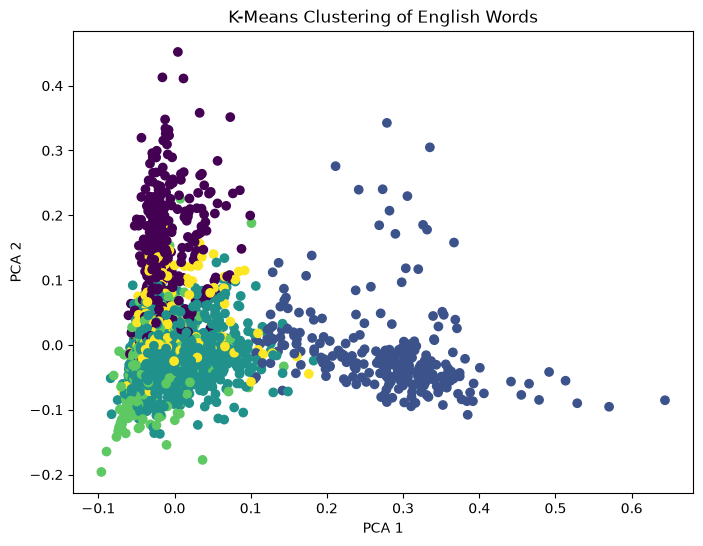

In [1]:
# Install if needed:
# !pip install pandas scikit-learn matplotlib nltk

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import nltk

nltk.download('wordnet')

# 1. Load dataset
df = pd.read_csv("4000-most-common-english-words-csv.csv")
print(df.head())
print(df.columns)

# 2. Select word column
word_col = df.select_dtypes(include='object').columns[0]
words = df[word_col].dropna().astype(str).str.lower()

# 3. NLP preprocessing
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

words = words.apply(lambda x: lemmatizer.lemmatize(x))
words = words[words.str.isalpha()].drop_duplicates()

# 4. Convert words to TF-IDF vectors
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5))
X = vectorizer.fit_transform(words)

# 5. K-Means clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# 6. Add cluster to dataset
result = pd.DataFrame({
    "word": words,
    "cluster": clusters
})

print("\nClustered Words:")
print(result.head(20))

# 7. Show words in each cluster
for i in range(k):
    print(f"\nCluster {i}:")
    print(result[result["cluster"] == i]["word"].head(20).tolist())

# 8. PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis")
plt.title("K-Means Clustering of English Words")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 9. Save results
result.to_csv("english_words_clusters.csv", index=False)